# IV. Bayesian Estimation 

**Research question:** What is the true probability that a diabetic patient is readmitted to the hospital?

**Model:** Beta-Binomial conjugate model  

In [2]:
# imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import beta as beta_dist

### 1. Load & Prepare Data

In [4]:
# load data 
df = pd.read_csv('../data/finaldiabetes.csv')

# encode 'readmitted' as binary for analysis
# 'readmitted' values: '<30' (within 30 days), '>30' (after 30 days), 'NO'
# readmission = any return to hospital ('<30' OR '>30')
df['readmitted_binary'] = (df['readmitted'] != 'NO').astype(int)

n_total   = len(df)
n_readmit = df['readmitted_binary'].sum()
n_no      = n_total - n_readmit
obs_rate  = n_readmit / n_total

print(f"Total encounters:  {n_total:,}")
print(f"Readmitted:        {n_readmit:,} ({obs_rate*100:.1f}%)")
print(f"Not readmitted:    {n_no:,} ({(1-obs_rate)*100:.1f}%)")
print()
print("Readmission breakdown:")
print(df['readmitted'].value_counts())

Total encounters:  101,766
Readmitted:        46,902 (46.1%)
Not readmitted:    54,864 (53.9%)

Readmission breakdown:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


### 2. Prior Distribution

We choose $\theta \sim \text{Beta}(5, 15)$ as our weakly informative prior.
- $\text{Beta}(5, 15)$ has mean $= 5/20 = 0.25$, encoding a conservative prior belief that roughly 1 in 4 patients is readmitted — clinically plausible without being too strong.
- Effective sample size of only 20 pseudo-observations is negligible relative to the dataset ($n \approx 100{,}000$), so the likelihood will dominate the posterior.

In [5]:
# prior parameters 

alpha_prior = 5
beta_prior  = 15

prior_mean = alpha_prior / (alpha_prior + beta_prior)
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Prior mean:                  {prior_mean:.3f}")
print(f"Prior effective sample size: {alpha_prior + beta_prior}")

Prior: Beta(5, 15)
Prior mean:                  0.250
Prior effective sample size: 20


### 3. Posterior Computation

We verify the conjugate result against grid approximation to make the Bayesian mechanics transparent.

In [7]:
# conjugate posterior
alpha_post = alpha_prior + n_readmit
beta_post  = beta_prior  + n_no

posterior   = beta_dist(alpha_post, beta_post)
post_mean   = posterior.mean()
post_median = posterior.median()
post_mode   = (alpha_post - 1) / (alpha_post + beta_post - 2)

print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"Posterior mean:   {post_mean:.5f}")
print(f"Posterior median: {post_median:.5f}")
print(f"Posterior mode:   {post_mode:.5f}")

# grid approximation 
theta_grid  = np.linspace(0.001, 0.999, 2000)
prior_pdf   = beta_dist(alpha_prior, beta_prior).pdf(theta_grid)
likelihood  = stats.binom.pmf(n_readmit, n_total, theta_grid)
unnorm_post = prior_pdf * likelihood
grid_post   = unnorm_post / np.trapezoid(unnorm_post, theta_grid)
exact_post  = posterior.pdf(theta_grid)

max_diff = np.max(np.abs(grid_post - exact_post))
print(f"\nGrid vs. exact posterior max difference: {max_diff:.2e}  (confirms conjugate derivation)")

Posterior: Beta(46907, 54879)
Posterior mean:   0.46084
Posterior median: 0.46084
Posterior mode:   0.46084

Grid vs. exact posterior max difference: 9.39e-10  (confirms conjugate derivation)


### 4. 95% Credible Interval

In [8]:
# 95% Equal-Tailed Credible Interval 
ci_lower, ci_upper = posterior.ppf([0.025, 0.975])

print(f"95% Credible Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")
print()
print("Interpretation:")
print(f"  Given the observed data and our prior, there is a 95% posterior")
print(f"  probability that the true readmission rate theta lies between")
print(f"  {ci_lower*100:.2f}% and {ci_upper*100:.2f}%.")

# Prior sensitivity check
post_flat         = beta_dist(1 + n_readmit, 1 + n_no)
ci_flat_l, ci_flat_u = post_flat.ppf([0.025, 0.975])
print(f"\nSensitivity check — Uninformative prior Beta(1, 1):")
print(f"  Posterior mean: {post_flat.mean():.5f}")
print(f"  95% CrI: [{ci_flat_l:.5f}, {ci_flat_u:.5f}]")
print(f"  -> Results nearly identical: the large n overwhelms the prior.")

95% Credible Interval: [0.45778, 0.46390]

Interpretation:
  Given the observed data and our prior, there is a 95% posterior
  probability that the true readmission rate theta lies between
  45.78% and 46.39%.

Sensitivity check — Uninformative prior Beta(1, 1):
  Posterior mean: 0.46088
  95% CrI: [0.45782, 0.46394]
  -> Results nearly identical: the large n overwhelms the prior.


### 5. Bayesian vs. Frequentist Comparison

In [9]:
# Frequentist MLE + Wald CI 
mle  = n_readmit / n_total
se   = np.sqrt(mle * (1 - mle) / n_total)
z    = 1.96
f_lo = mle - z * se
f_hi = mle + z * se

# Wilson score interval (more accurate for proportions)
w_center = (mle + z**2 / (2*n_total)) / (1 + z**2 / n_total)
w_margin = (z * np.sqrt(mle*(1-mle)/n_total + z**2/(4*n_total**2))) / (1 + z**2/n_total)
w_lo, w_hi = w_center - w_margin, w_center + w_margin

print("─" * 68)
print(f"{'Method':<32} {'Estimate':>10} {'Lower 95%':>10} {'Upper 95%':>10}")
print("─" * 68)
print(f"{'Frequentist MLE (Wald CI)':<32} {mle:>10.5f} {f_lo:>10.5f} {f_hi:>10.5f}")
print(f"{'Frequentist MLE (Wilson CI)':<32} {mle:>10.5f} {w_lo:>10.5f} {w_hi:>10.5f}")
print(f"{'Bayesian Beta(5,15) prior':<32} {post_mean:>10.5f} {ci_lower:>10.5f} {ci_upper:>10.5f}")
print(f"{'Bayesian Beta(1,1) prior':<32} {post_flat.mean():>10.5f} {ci_flat_l:>10.5f} {ci_flat_u:>10.5f}")
print("─" * 68)

────────────────────────────────────────────────────────────────────
Method                             Estimate  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────
Frequentist MLE (Wald CI)           0.46088    0.45782    0.46394
Frequentist MLE (Wilson CI)         0.46088    0.45782    0.46394
Bayesian Beta(5,15) prior           0.46084    0.45778    0.46390
Bayesian Beta(1,1) prior            0.46088    0.45782    0.46394
────────────────────────────────────────────────────────────────────


In [10]:
print("""
Interpretive Difference:

  Frequentist 95% CI:
    If this study were repeated infinitely, 95% of constructed intervals
    would contain the true fixed (but unknown) parameter theta.
    The parameter itself has no probability distribution.

  Bayesian 95% Credible Interval:
    Given the data, P(ci_lower < theta < ci_upper | data) = 0.95.
    This is a direct probability statement about theta — the interpretation
    most people intuitively want from an interval estimate.

  Numerical agreement:
    With a large n, both approaches converge. The Bayesian posterior mean
    slightly shrinks toward the prior mean, but this effect is negligible
    at this sample size, confirming the data dominates over the prior.
""")


Interpretive Difference:

  Frequentist 95% CI:
    If this study were repeated infinitely, 95% of constructed intervals
    would contain the true fixed (but unknown) parameter theta.
    The parameter itself has no probability distribution.

  Bayesian 95% Credible Interval:
    Given the data, P(ci_lower < theta < ci_upper | data) = 0.95.
    This is a direct probability statement about theta — the interpretation
    most people intuitively want from an interval estimate.

  Numerical agreement:
    With a large n, both approaches converge. The Bayesian posterior mean
    slightly shrinks toward the prior mean, but this effect is negligible
    at this sample size, confirming the data dominates over the prior.



### 6. Visualization 

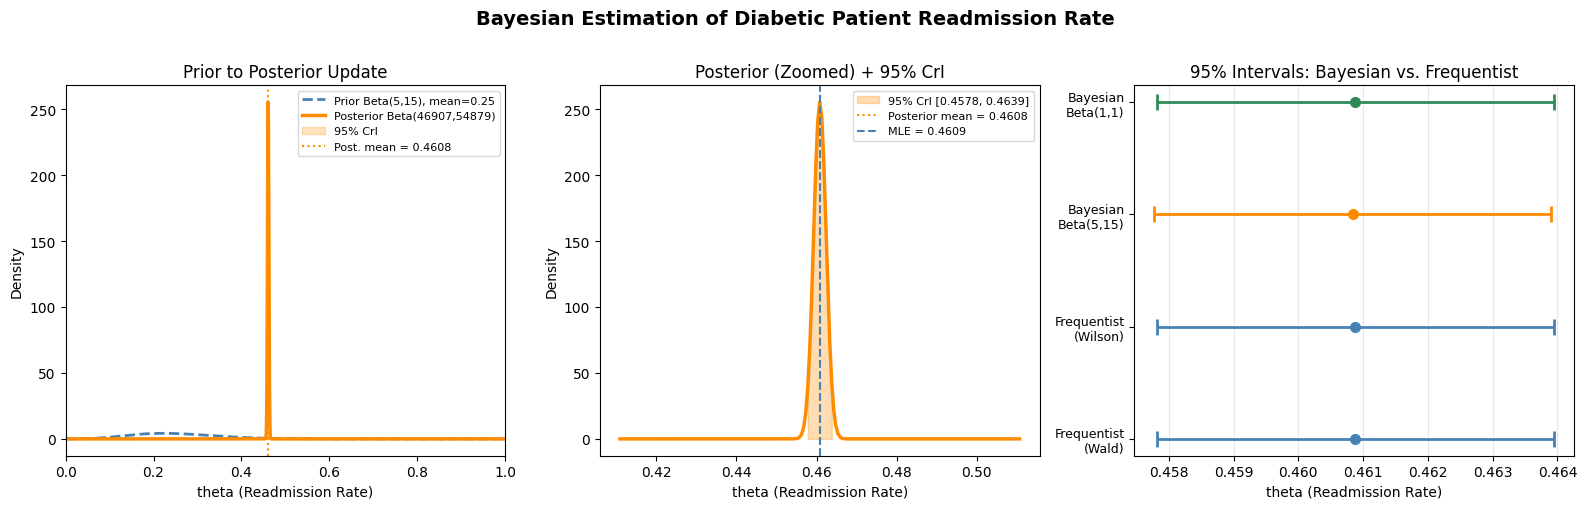

Plot saved.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bayesian Estimation of Diabetic Patient Readmission Rate',
             fontsize=14, fontweight='bold', y=1.01)

zoom = (theta_grid > post_mean - 0.05) & (theta_grid < post_mean + 0.05)
mask = (theta_grid >= ci_lower) & (theta_grid <= ci_upper)

# Panel 1: Full prior -> posterior update
ax = axes[0]
ax.plot(theta_grid, prior_pdf,  color='steelblue',  lw=2,   ls='--',
        label=f'Prior Beta({alpha_prior},{beta_prior}), mean={prior_mean:.2f}')
ax.plot(theta_grid, exact_post, color='darkorange',  lw=2.5,
        label=f'Posterior Beta({alpha_post},{beta_post})')
ax.fill_between(theta_grid[mask], exact_post[mask],
                alpha=0.25, color='darkorange', label='95% CrI')
ax.axvline(post_mean, color='darkorange', lw=1.5, ls=':',
           label=f'Post. mean = {post_mean:.4f}')
ax.set_xlabel('theta (Readmission Rate)')
ax.set_ylabel('Density')
ax.set_title('Prior to Posterior Update')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

# Panel 2: Zoomed posterior + CrI 
ax2 = axes[1]
ax2.plot(theta_grid[zoom], exact_post[zoom], color='darkorange', lw=2.5)
mask_z = mask & zoom
ax2.fill_between(theta_grid[mask_z], exact_post[mask_z],
                 alpha=0.3, color='darkorange',
                 label=f'95% CrI [{ci_lower:.4f}, {ci_upper:.4f}]')
ax2.axvline(post_mean, color='darkorange', lw=1.5, ls=':',
            label=f'Posterior mean = {post_mean:.4f}')
ax2.axvline(mle, color='steelblue', lw=1.5, ls='--',
            label=f'MLE = {mle:.4f}')
ax2.set_xlabel('theta (Readmission Rate)')
ax2.set_ylabel('Density')
ax2.set_title('Posterior (Zoomed) + 95% CrI')
ax2.legend(fontsize=8)

# Panel 3: Interval comparison 
ax3 = axes[2]
methods = ['Frequentist\n(Wald)', 'Frequentist\n(Wilson)',
           'Bayesian\nBeta(5,15)', 'Bayesian\nBeta(1,1)']
means   = [mle,    mle,    post_mean,       post_flat.mean()]
lowers  = [f_lo,   w_lo,   ci_lower,        ci_flat_l]
uppers  = [f_hi,   w_hi,   ci_upper,        ci_flat_u]
colors  = ['steelblue', 'steelblue', 'darkorange', 'seagreen']

for i, (m, lo, hi, c) in enumerate(zip(means, lowers, uppers, colors)):
    ax3.errorbar(m, i, xerr=[[m - lo], [hi - m]],
                 fmt='o', color=c, capsize=6, capthick=2,
                 elinewidth=2, markersize=7)
ax3.set_yticks(range(len(methods)))
ax3.set_yticklabels(methods, fontsize=9)
ax3.set_xlabel('theta (Readmission Rate)')
ax3.set_title('95% Intervals: Bayesian vs. Frequentist')
ax3.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('bayesian_readmission.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")